# Exploratory Data Analysis (EDA) - Training Impact Dataset

## Objective
This notebook performs comprehensive exploratory data analysis on the training impact dataset before building machine learning models.

### Analysis Goals:
1. Understand dataset structure and data types
2. Identify missing values and data quality issues
3. Explore distributions of categorical and numeric variables
4. Analyze correlations between features
5. Identify candidate variables for key ML targets:
   - Dependency Risk Classification
   - Motivation Score Prediction
   - Digital Self-Efficacy Assessment

### Outcomes:
This EDA informs feature engineering and model design for subsequent ML notebooks (e.g., 01_risk_dependency.ipynb).

In [1]:
# Import required libraries for exploratory data analysis
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load environment variables from .env file
from dotenv import load_dotenv
load_dotenv('/workspaces/EvaluAI/.env')

# Configure visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)

In [2]:
# Load the dataset
# Use absolute path to ensure it works from any working directory
data_path = '/workspaces/EvaluAI/backend/data/raw/EIPIA_FO_dataset_100_personas.csv'

print(f"Loading dataset from: {data_path}")
print(f"File exists: {os.path.exists(data_path)}")

if not os.path.exists(data_path):
    raise FileNotFoundError(f"Dataset not found at: {data_path}")

# Load the CSV file (uses semicolon as delimiter)
df = pd.read_csv(data_path, sep=';')
print(f"✓ Dataset loaded successfully!")
print(f"Shape: {df.shape}")

Loading dataset from: /workspaces/EvaluAI/backend/data/raw/EIPIA_FO_dataset_100_personas.csv
File exists: True
✓ Dataset loaded successfully!
Shape: (100, 41)


In [3]:
# Display dataset shape and basic information
print("\n" + "="*70)
print("DATASET STRUCTURE / ESTRUCTURA DEL DATASET")
print("="*70)

print(f"\nDataset Dimensions:")
print(f"  Rows: {df.shape[0]}")
print(f"  Columns: {df.shape[1]}")print(f"  Filas: {df.shape[0]}")
print(f"  Columnas: {df.shape[1]}")

print(f"\nColumn Names and Data Types:")
print(df.dtypes)print(df.dtypes)

print(f"\nMemory Usage: {df.memory_usage(deep=True).sum() / 1024:.2f} KB")



DATASET STRUCTURE / ESTRUCTURA DEL DATASET

|EN| Dataset Dimensions:
  Rows: 100
  Columns: 41

|ES| Dimensiones del Dataset:
  Filas: 100
  Columnas: 41

|EN| Column Names and Data Types:
id_empleado                 object
edad                         int64
genero                      object
departamento                object
antiguedad_empresa           int64
nivel_educativo             object
rol_tecnico                  int64
sector                      object
frecuencia_uso_ia            int64
usa_chatgpt                  int64
usa_gemini                   int64
usa_copilot                  int64
usa_lms_ia                   int64
usa_otra_ia                  int64
herramienta_principal       object
prefiere_humano_vs_ia        int64
nivel_integracion_ia         int64
AT1_rendimiento              int64
AT2_facilita_aprendizaje     int64
AT3_facilidad_uso            int64
AT4_integracion_positiva     int64
AE1_resolver_problemas       int64
AE2_confianza_digital        int64
AE3_u

In [4]:
# Analyze missing values
print("\n" + "="*70)
print("MISSING VALUES ANALYSIS / ANÁLISIS DE VALORES FALTANTES")
print("="*70)

# Calculate missing values
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing_counts.index,
    'Missing_Count': missing_counts.values,
    'Percentage': missing_percent.values
}).sort_values('Missing_Count', ascending=False)

# Display columns with missing values
missing_with_data = missing_df[missing_df['Missing_Count'] > 0]
if len(missing_with_data) > 0:
    print(f"\nColumns with missing values ({len(missing_with_data)}):")
    print(missing_with_data.to_string(index=False))    print(missing_with_data.to_string(index=False))
else:
    print(f"\n✓ No missing values found in the dataset!")
# Summary statistics
total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
print(f"\nOverall Data Completeness:")
print(f"  Total cells: {total_cells:,}")
print(f"  Missing cells: {total_missing:,}")
print(f"  Completeness: {((total_cells - total_missing) / total_cells * 100):.2f}%")print(f"  Total de celdas: {total_cells:,}")
print(f"  Celdas faltantes: {total_missing:,}")
print(f"  Completitud: {((total_cells - total_missing) / total_cells * 100):.2f}%")


MISSING VALUES ANALYSIS / ANÁLISIS DE VALORES FALTANTES

✓ |EN| No missing values found in the dataset!

✓ |ES| ¡No se encontraron valores faltantes en el dataset!

|EN| Overall Data Completeness:
  Total cells: 4,100
  Missing cells: 0
  Completeness: 100.00%

|ES| Completitud General de Datos:
  Total de celdas: 4,100
  Celdas faltantes: 0
  Completitud: 100.00%


In [5]:
# Identify categorical and numeric columns
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print("\n" + "="*70)
print("FEATURE TYPES / TIPOS DE CARACTERÍSTICAS")
print("="*70)

print(f"\nCategorical Variables ({len(categorical_cols)}):")
for col in categorical_cols:
    print(f"  - {col}")for col in categorical_cols:
    print(f"  - {col}")

print(f"\nNumeric Variables ({len(numeric_cols)}):")
for col in numeric_cols:
    print(f"  - {col}")for col in numeric_cols:
    print(f"  - {col}")


FEATURE TYPES / TIPOS DE CARACTERÍSTICAS

|EN| Categorical Variables (6):
  - id_empleado
  - genero
  - departamento
  - nivel_educativo
  - sector
  - herramienta_principal

|ES| Variables Categóricas (6):
  - id_empleado
  - genero
  - departamento
  - nivel_educativo
  - sector
  - herramienta_principal

|EN| Numeric Variables (35):
  - edad
  - antiguedad_empresa
  - rol_tecnico
  - frecuencia_uso_ia
  - usa_chatgpt
  - usa_gemini
  - usa_copilot
  - usa_lms_ia
  - usa_otra_ia
  - prefiere_humano_vs_ia
  - nivel_integracion_ia
  - AT1_rendimiento
  - AT2_facilita_aprendizaje
  - AT3_facilidad_uso
  - AT4_integracion_positiva
  - AE1_resolver_problemas
  - AE2_confianza_digital
  - AE3_uso_eficaz
  - AE4_seguridad_aplicacion
  - M1_estimulante
  - M2_aumenta_interes
  - M3_aporta_valor
  - M4_mayor_esfuerzo
  - E1_adaptacion
  - E2_feedback_util
  - E3_aplicable_trabajo
  - E4_aprendizaje_ritmo
  - D1_mejora_competencias
  - D2_preparado_retos
  - D3_amplia_habilidades
  - D4_apre

In [6]:
# Display first few rows
print("\n" + "="*70)
print("FIRST 5 ROWS OF DATA")
print("="*70)
print(df.head().to_string())


FIRST 5 ROWS OF DATA
  id_empleado  edad      genero departamento  antiguedad_empresa nivel_educativo  rol_tecnico      sector  frecuencia_uso_ia  usa_chatgpt  usa_gemini  usa_copilot  usa_lms_ia  usa_otra_ia herramienta_principal  prefiere_humano_vs_ia  nivel_integracion_ia  AT1_rendimiento  AT2_facilita_aprendizaje  AT3_facilidad_uso  AT4_integracion_positiva  AE1_resolver_problemas  AE2_confianza_digital  AE3_uso_eficaz  AE4_seguridad_aplicacion  M1_estimulante  M2_aumenta_interes  M3_aporta_valor  M4_mayor_esfuerzo  E1_adaptacion  E2_feedback_util  E3_aplicable_trabajo  E4_aprendizaje_ritmo  D1_mejora_competencias  D2_preparado_retos  D3_amplia_habilidades  D4_aprendizaje_autonomo  C1_confio_sin_verificar  C2_dificil_sin_ia  C3_pensamiento_critico  C4_reflexiono_calidad
0    1XVWCBPH    50       Mujer           IT                  17          Máster            0   Servicios                  2            1           1            0           0            0                Gemini     

In [7]:
# Basic statistical summary for numeric variables
print("\n" + "="*70)
print("NUMERIC VARIABLES - STATISTICAL SUMMARY")
print("="*70)
print(df[numeric_cols].describe().to_string())


NUMERIC VARIABLES - STATISTICAL SUMMARY
             edad  antiguedad_empresa  rol_tecnico  frecuencia_uso_ia  usa_chatgpt  usa_gemini  usa_copilot  usa_lms_ia  usa_otra_ia  prefiere_humano_vs_ia  nivel_integracion_ia  AT1_rendimiento  AT2_facilita_aprendizaje  AT3_facilidad_uso  AT4_integracion_positiva  AE1_resolver_problemas  AE2_confianza_digital  AE3_uso_eficaz  AE4_seguridad_aplicacion  M1_estimulante  M2_aumenta_interes  M3_aporta_valor  M4_mayor_esfuerzo  E1_adaptacion  E2_feedback_util  E3_aplicable_trabajo  E4_aprendizaje_ritmo  D1_mejora_competencias  D2_preparado_retos  D3_amplia_habilidades  D4_aprendizaje_autonomo  C1_confio_sin_verificar  C2_dificil_sin_ia  C3_pensamiento_critico  C4_reflexiono_calidad
count  100.000000          100.000000   100.000000         100.000000   100.000000  100.000000       100.00  100.000000       100.00             100.000000            100.000000       100.000000                100.000000         100.000000                100.000000       

In [8]:
# Analyze categorical variables - value counts
print("\n" + "="*70)
print("CATEGORICAL VARIABLES - VALUE COUNTS")
print("="*70)

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"  Unique values: {df[col].nunique()}")


CATEGORICAL VARIABLES - VALUE COUNTS

id_empleado:
id_empleado
1XVWCBPH    1
X74JR294    1
5XB7VFBA    1
GFIHG8IV    1
ITKBRRUW    1
7RX39N06    1
4P5A6WSA    1
9EU1EBBT    1
KWA0LO28    1
9Q7QOXVK    1
L78CAFV7    1
VVOOQGPQ    1
278P10CH    1
MMY0MFRF    1
19SQKX5N    1
LR68JT6U    1
XBBOBM1B    1
VUDJ2W4I    1
EM2B4BE3    1
UJDIS36H    1
5KXU47DO    1
IYVVNZW4    1
8AALCGFM    1
2X97Z1HI    1
OMUG1PZQ    1
UQKX9AD5    1
C6B6UEUO    1
RRJSW7HR    1
33PBC9A6    1
DOWPLEP6    1
F77EBBJ2    1
SFNC52M9    1
4O307BAB    1
TOQH67SQ    1
RULNX07S    1
JQU7LEG6    1
QDJUBLXU    1
YSWGNH2Y    1
L3S1ODX6    1
V32IKNL0    1
DA3ZPQQ8    1
8INARFO9    1
R2GMK38F    1
0970I8H9    1
GMIQJ40G    1
RSGDHC0X    1
OEPMB5LI    1
OW8T36AU    1
3SF1E10Q    1
5P3GZHA0    1
O60RLJA4    1
Z4143ZJS    1
MNKKD5GF    1
P8W24GGV    1
SF2J54CS    1
095E5TQ1    1
GMDCVHV8    1
NHJA8WAV    1
PUFFAGMR    1
JCDVVJ4R    1
WB2U52AH    1
56354NYY    1
Q90LO3MT    1
9DLT8ADA    1
795UT2G3    1
Q8BM5AHU    1
UOB0BD7F    


NUMERIC VARIABLES - DISTRIBUTION HISTOGRAMS
VARIABLES NUMÉRICAS - HISTOGRAMAS DE DISTRIBUCIÓN


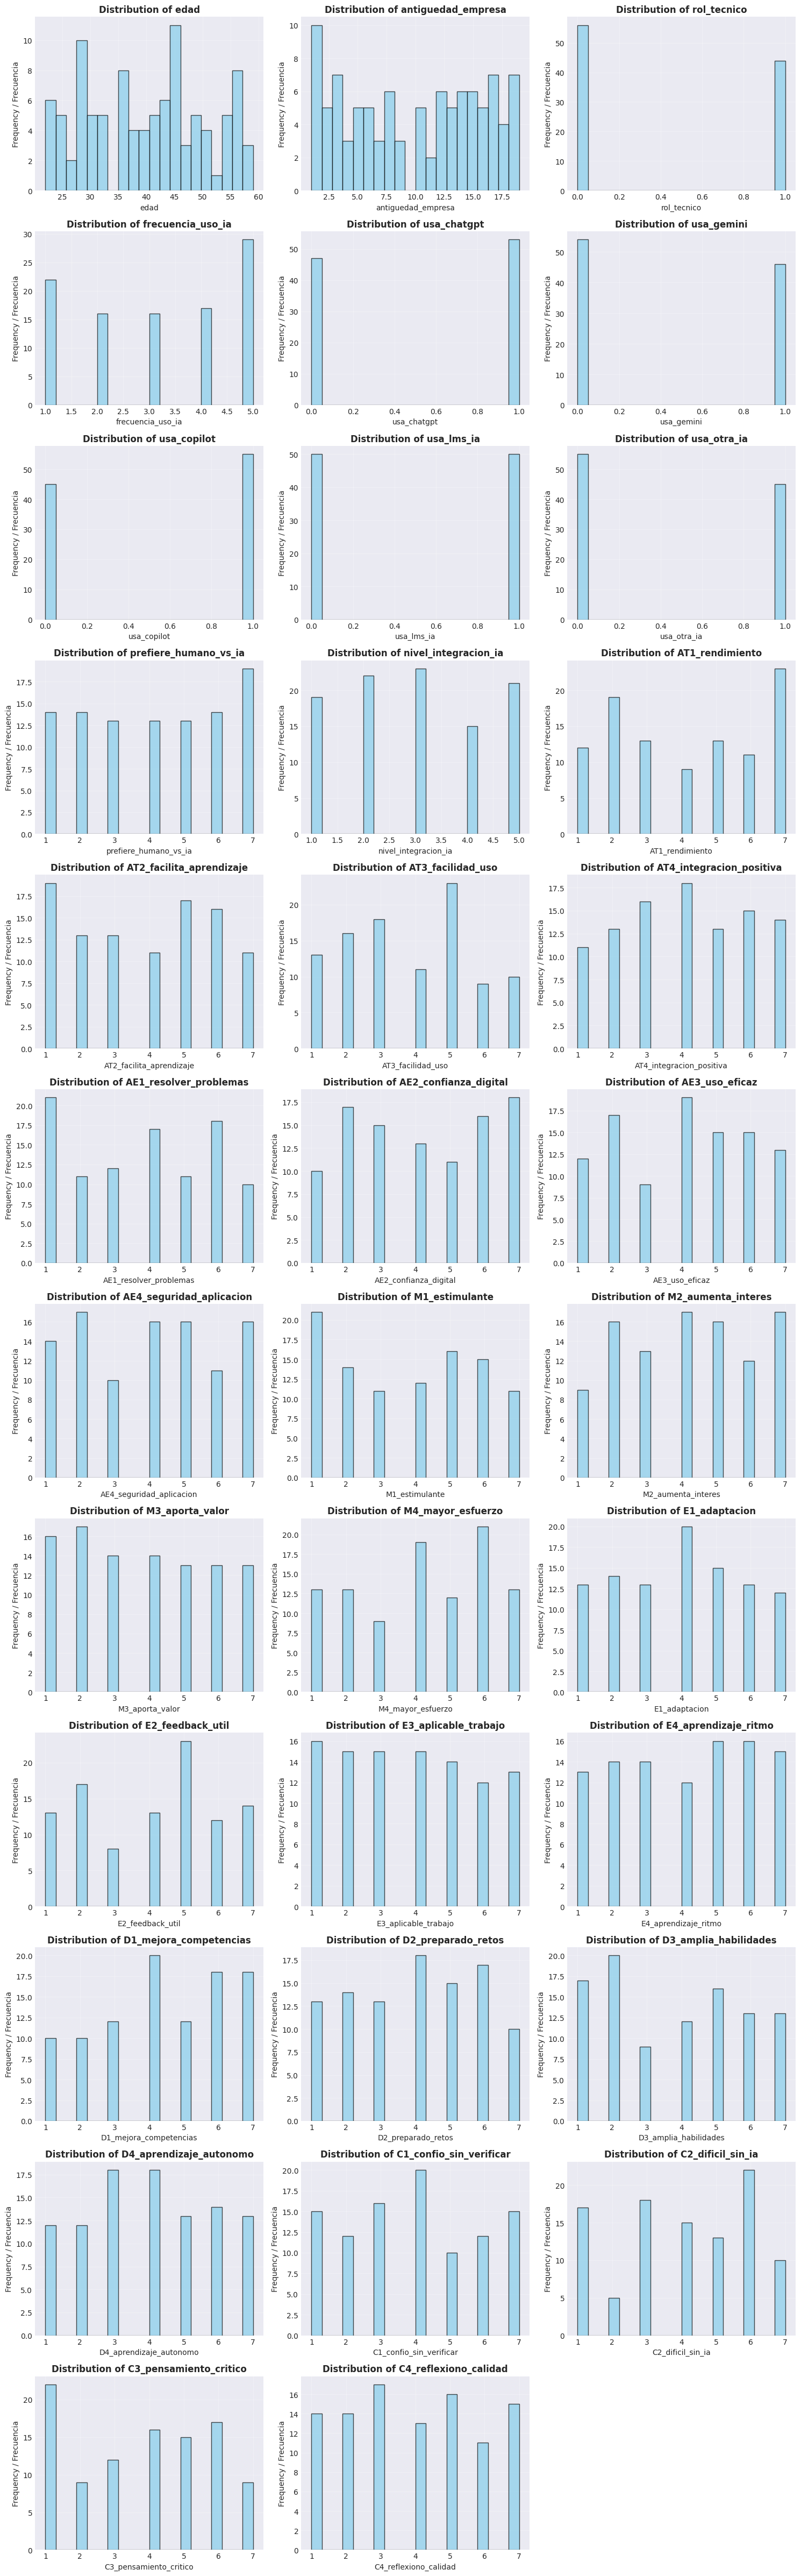


✓ |EN| Histograms plotted for 35 numeric variables
✓ |ES| Histogramas generados para 35 variables numéricas


In [9]:
# Plot histograms for all numeric variables
print("\n" + "="*70)
print("NUMERIC VARIABLES - DISTRIBUTION HISTOGRAMS")
print("VARIABLES NUMÉRICAS - HISTOGRAMAS DE DISTRIBUCIÓN")
print("="*70)

# Calculate grid dimensions
n_cols = len(numeric_cols)
n_rows = (n_cols + 2) // 3  # Ceiling division for 3 columns per row

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 4*n_rows))
axes = axes.flatten()  # Flatten for easier iteration

# Create histogram for each numeric variable
for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Plot histogram with KDE overlay
    ax.hist(df[col].dropna(), bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequency / Frecuencia', fontsize=10)
    ax.grid(True, alpha=0.3)

# Remove empty subplots
for idx in range(n_cols, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print(f"\n✓ Histograms plotted for {n_cols} numeric variables")
print(f"✓ Histogramas generados para {n_cols} variables numéricas")


CATEGORICAL VARIABLES - DISTRIBUTION BAR CHARTS
VARIABLES CATEGÓRICAS - GRÁFICOS DE DISTRIBUCIÓN


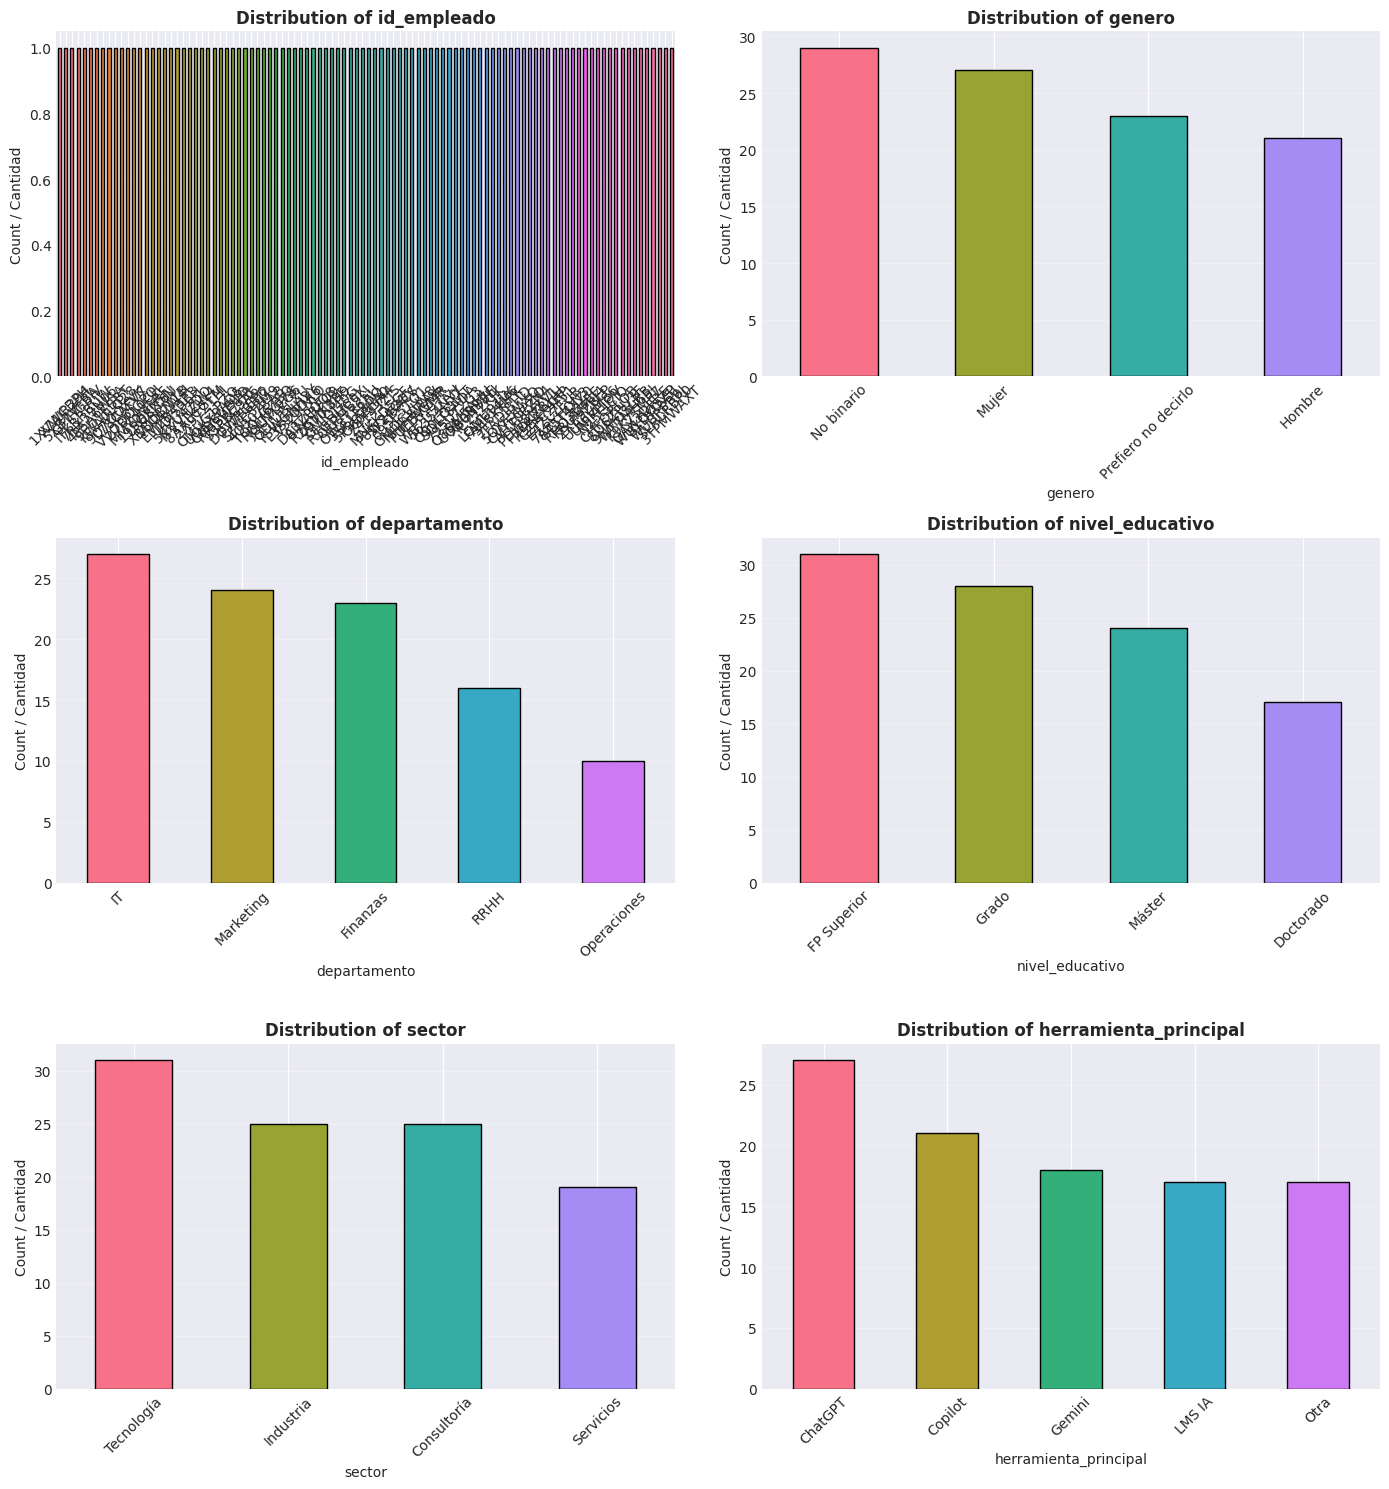


✓ |EN| Bar charts plotted for 6 categorical variables
✓ |ES| Gráficos de barras generados para 6 variables categóricas


In [10]:
# Plot categorical variables as bar charts
print("\nCATEGORICAL VARIABLES - DISTRIBUTION BAR CHARTS")
print("VARIABLES CATEGÓRICAS - GRÁFICOS DE DISTRIBUCIÓN")
print("="*70)

n_cat_cols = len(categorical_cols)
n_rows_cat = (n_cat_cols + 1) // 2  # Ceiling division for 2 columns per row

fig, axes = plt.subplots(n_rows_cat, 2, figsize=(14, 5*n_rows_cat))
axes = axes.flatten()

# Create bar chart for each categorical variable
for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    
    # Get value counts and plot
    value_counts = df[col].value_counts()
    colors = sns.color_palette('husl', len(value_counts))
    value_counts.plot(kind='bar', ax=ax, color=colors, edgecolor='black')
    ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Count / Cantidad', fontsize=10)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

# Remove empty subplots
for idx in range(n_cat_cols, len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print(f"\n✓ Bar charts plotted for {n_cat_cols} categorical variables")
print(f"✓ Gráficos de barras generados para {n_cat_cols} variables categóricas")


CORRELATION ANALYSIS - NUMERIC FEATURES
ANÁLISIS DE CORRELACIONES - CARACTERÍSTICAS NUMÉRICAS

Correlation Matrix (35x35):
Matriz de Correlaciones (35x35):
                              edad  antiguedad_empresa  rol_tecnico  frecuencia_uso_ia  usa_chatgpt    usa_gemini  usa_copilot    usa_lms_ia  usa_otra_ia  prefiere_humano_vs_ia  nivel_integracion_ia  AT1_rendimiento  AT2_facilita_aprendizaje  AT3_facilidad_uso  AT4_integracion_positiva  AE1_resolver_problemas  AE2_confianza_digital  AE3_uso_eficaz  AE4_seguridad_aplicacion  M1_estimulante  M2_aumenta_interes  M3_aporta_valor  M4_mayor_esfuerzo  E1_adaptacion  E2_feedback_util  E3_aplicable_trabajo  E4_aprendizaje_ritmo  D1_mejora_competencias  D2_preparado_retos  D3_amplia_habilidades  D4_aprendizaje_autonomo  C1_confio_sin_verificar  C2_dificil_sin_ia  C3_pensamiento_critico  C4_reflexiono_calidad
edad                      1.000000            0.081757     0.042357          -0.061925     0.114587  7.403359e-02    -0.132875 -1.31644

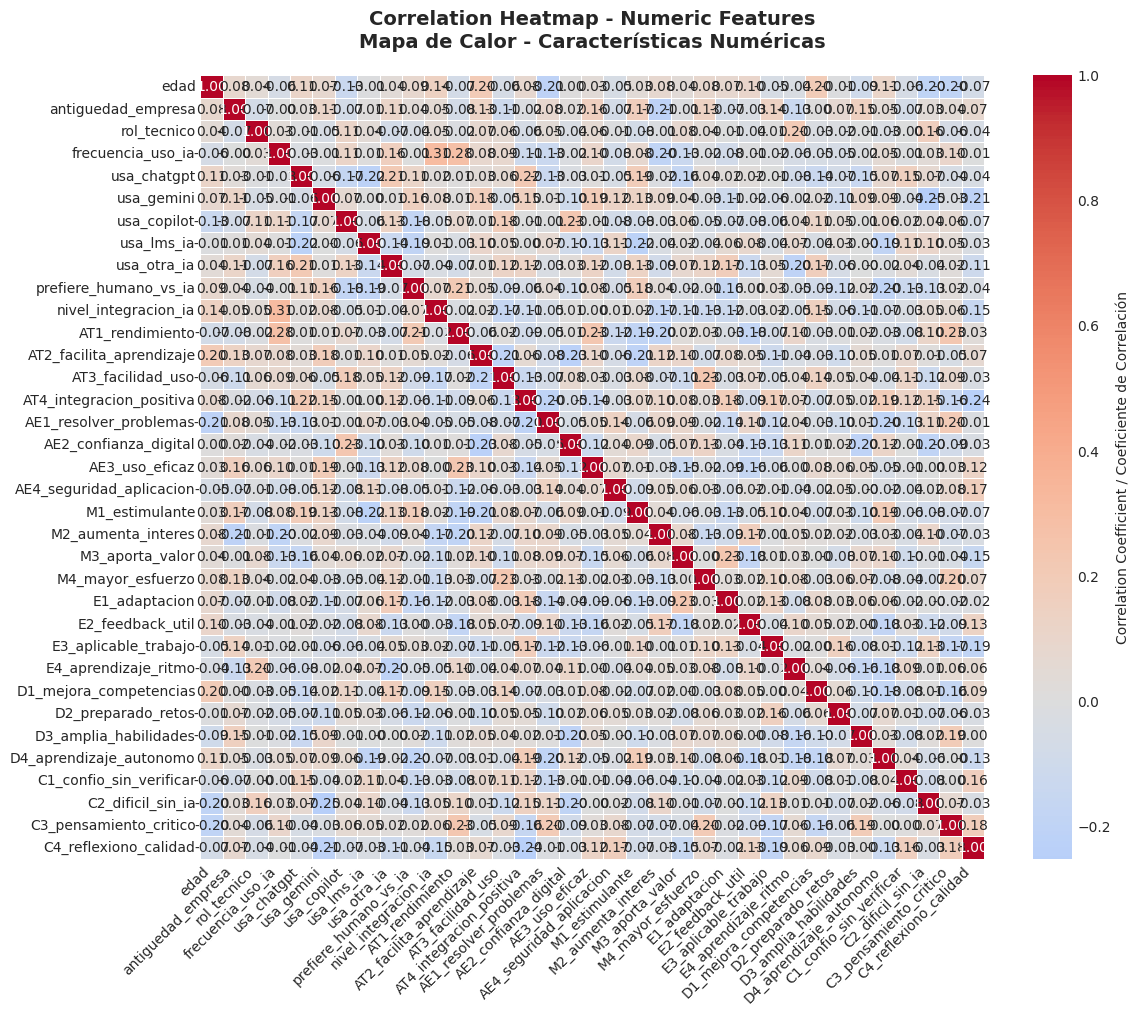


✓ |EN| Correlation heatmap generated
✓ |ES| Mapa de calor de correlaciones generado


In [11]:
# Compute and plot correlation matrix for numeric variables
print("\n" + "="*70)
print("CORRELATION ANALYSIS - NUMERIC FEATURES")
print("ANÁLISIS DE CORRELACIONES - CARACTERÍSTICAS NUMÉRICAS")
print("="*70)

# Calculate correlation matrix
correlation_matrix = df[numeric_cols].corr()

# Display correlation matrix
print(f"\nCorrelation Matrix ({len(numeric_cols)}x{len(numeric_cols)}):")
print(f"Matriz de Correlaciones ({len(numeric_cols)}x{len(numeric_cols)}):")
print(correlation_matrix.to_string())

# Plot correlation heatmap
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'label': 'Correlation Coefficient / Coeficiente de Correlación'},
    ax=ax
)
ax.set_title('Correlation Heatmap - Numeric Features\nMapa de Calor - Características Numéricas', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f"\n✓ Correlation heatmap generated")
print(f"✓ Mapa de calor de correlaciones generado")

In [12]:
# Identify strong correlations (abs value > 0.7)
print("\nSTRONG CORRELATIONS (|r| > 0.7) / CORRELACIONES FUERTES (|r| > 0.7):")
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            strong_corr.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

if strong_corr:
    for col1, col2, corr_val in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
        print(f"  {col1} <-> {col2}: {corr_val:.4f}")
else:
    print("  No strong correlations found")
    print("  No se encontraron correlaciones fuertes")


STRONG CORRELATIONS (|r| > 0.7) / CORRELACIONES FUERTES (|r| > 0.7):
  |EN| No strong correlations found
  |ES| No se encontraron correlaciones fuertes


In [13]:
# Identify candidate variables for ML targets
print("\n" + "="*70)
print("CANDIDATE VARIABLES FOR ML TARGETS")
print("="*70)

print("\n1. DEPENDENCY RISK CLASSIFICATION:")
print("   Target: Predict if employee has 'high' dependency risk")
if 'dependency_risk_level' in df.columns:
    print(f"   ✓ Target Variable Found: 'dependency_risk_level'")
    print(f"     Unique values: {df['dependency_risk_level'].unique().tolist()}")
    print(f"     Distribution:\n{df['dependency_risk_level'].value_counts()}")
else:
    print(f"   ✗ No 'dependency_risk_level' column found")

# Find correlated features
dependency_candidates = []
for col in numeric_cols:
    if col != 'dependency_risk_level':
        # Assuming dependency_risk_high would be created as binary
        dependency_candidates.append(col)

print(f"   Candidate Features: {len(numeric_cols) - (1 if 'dependency_risk_level' in numeric_cols else 0)} numeric variables")
print(f"   {', '.join(numeric_cols[:min(5, len(numeric_cols))])}...")


CANDIDATE VARIABLES FOR ML TARGETS

1. DEPENDENCY RISK CLASSIFICATION:
   Target: Predict if employee has 'high' dependency risk
   ✗ No 'dependency_risk_level' column found
   Candidate Features: 35 numeric variables
   edad, antiguedad_empresa, rol_tecnico, frecuencia_uso_ia, usa_chatgpt...


In [14]:
print("\n2. MOTIVATION SCORE PREDICTION:")
print("   Target: Predict employee motivation level")
if 'motivation' in df.columns or 'avg_motivation' in df.columns:
    motivation_col = 'motivation' if 'motivation' in df.columns else 'avg_motivation'
    print(f"   ✓ Target Variable Found: '{motivation_col}'")
    print(f"     Type: {df[motivation_col].dtype}")
    print(f"     Statistics:\n{df[motivation_col].describe()}")
else:
    print(f"   ? Potential target variables (check manually):")
    potential_motivation = [col for col in df.columns if 'motiv' in col.lower()]
    if potential_motivation:
        print(f"     {', '.join(potential_motivation)}")
    else:
        print(f"     No obvious motivation columns found")

print(f"   Candidate Features: Numeric variables excluding motivation scores")
print(f"   {', '.join([col for col in numeric_cols if 'motiv' not in col.lower()][:5])}...")


2. MOTIVATION SCORE PREDICTION:
   Target: Predict employee motivation level
   ? Potential target variables (check manually):
     No obvious motivation columns found
   Candidate Features: Numeric variables excluding motivation scores
   edad, antiguedad_empresa, rol_tecnico, frecuencia_uso_ia, usa_chatgpt...


In [15]:
print("\n3. DIGITAL SELF-EFFICACY ASSESSMENT:")
print("   Target: Predict employee digital self-efficacy level")
if 'self_efficacy' in df.columns or 'digital_self_efficacy' in df.columns or 'autoeficacia' in df.columns:
    efficacy_candidates = [col for col in df.columns if any(term in col.lower() for term in ['efficacy', 'eficacia', 'self_eff'])]
    print(f"   ✓ Target Variable(s) Found: {efficacy_candidates}")
    for col in efficacy_candidates:
        print(f"     {col}: {df[col].dtype}")
        print(f"       Statistics: {df[col].describe().to_dict()}")
else:
    print(f"   ? Potential target variables (check manually):")
    potential_efficacy = [col for col in df.columns if any(term in col.lower() for term in ['efficacy', 'eficacia', 'efficaz'])]
    if potential_efficacy:
        print(f"     {', '.join(potential_efficacy)}")
    else:
        print(f"     No obvious self-efficacy columns found")

print(f"   Candidate Features: Numeric variables related to AI usage, learning")
print(f"   {', '.join([col for col in numeric_cols if 'efficacy' not in col.lower()][:5])}...")

print("\n" + "="*70)
print("✓ EDA COMPLETE / ANÁLISIS EXPLORATORIO COMPLETO")
print("Ready for Feature Engineering & ML Modeling")
print("Listo para Ingeniería de Características y Modelado ML")
print("="*70)


3. DIGITAL SELF-EFFICACY ASSESSMENT:
   Target: Predict employee digital self-efficacy level
   ? Potential target variables (check manually):
     No obvious self-efficacy columns found
   Candidate Features: Numeric variables related to AI usage, learning
   edad, antiguedad_empresa, rol_tecnico, frecuencia_uso_ia, usa_chatgpt...

✓ EDA COMPLETE / ANÁLISIS EXPLORATORIO COMPLETO
Ready for Feature Engineering & ML Modeling
Listo para Ingeniería de Características y Modelado ML


In [16]:
# Summary statistics for ML preparation
print("\nSUMMARY FOR ML PREPARATION:")
print("\nDataset Readiness:")
print(f"  ✓ Total Records: {len(df)}")
print(f"  ✓ Total Features: {len(df.columns)}")
print(f"  ✓ Numeric Features: {len(numeric_cols)}")
print(f"  ✓ Categorical Features: {len(categorical_cols)}")
print(f"  ✓ Data Completeness: {((total_cells - total_missing) / total_cells * 100):.2f}%")
print(f"\nNext Steps:")
print(f"  1. Review candidate target variables")
print(f"  2. Handle categorical variables (encoding/dummification)")
print(f"  3. Scale numeric features if needed")
print(f"  4. Create binary targets for classification models")
print(f"  5. Run 01_risk_dependency.ipynb for dependency risk model")

print("\nRESUMEN PARA PREPARACIÓN ML:")
print("\nPreparación del Dataset:")
print(f"  ✓ Total de Registros: {len(df)}")
print(f"  ✓ Total de Características: {len(df.columns)}")
print(f"  ✓ Características Numéricas: {len(numeric_cols)}")
print(f"  ✓ Características Categóricas: {len(categorical_cols)}")
print(f"  ✓ Completitud de Datos: {((total_cells - total_missing) / total_cells * 100):.2f}%")print(f"  1. Revisar variables objetivo candidatas")
print(f"  2. Manejar variables categóricas (codificación/dummificación)")
print(f"  3. Escalar características numéricas si es necesario")
print(f"  4. Crear objetivos binarios para modelos de clasificación")
print(f"  5. Ejecutar 01_risk_dependency.ipynb para modelo de riesgo de dependencia")


|EN| SUMMARY FOR ML PREPARATION:

|EN| Dataset Readiness:
  ✓ Total Records: 100
  ✓ Total Features: 41
  ✓ Numeric Features: 35
  ✓ Categorical Features: 6
  ✓ Data Completeness: 100.00%

|EN| Next Steps:
  1. Review candidate target variables
  2. Handle categorical variables (encoding/dummification)
  3. Scale numeric features if needed
  4. Create binary targets for classification models
  5. Run 01_risk_dependency.ipynb for dependency risk model

|ES| RESUMEN PARA PREPARACIÓN ML:

|ES| Preparación del Dataset:
  ✓ Total de Registros: 100
  ✓ Total de Características: 41
  ✓ Características Numéricas: 35
  ✓ Características Categóricas: 6
  ✓ Completitud de Datos: 100.00%

|ES| Próximos Pasos:
  1. Revisar variables objetivo candidatas
  2. Manejar variables categóricas (codificación/dummificación)
  3. Escalar características numéricas si es necesario
  4. Crear objetivos binarios para modelos de clasificación
  5. Ejecutar 01_risk_dependency.ipynb para modelo de riesgo de depend